<a href="https://colab.research.google.com/github/lavginjupalli-star/Learning/blob/main/Course_7_Week_5_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Why R² alone is not enough

R² tells us how well the model fits the data it sees

A high R² on training data can be misleading

Models can memorize data (overfitting) instead of learning patterns

So R² answers:

“How well did the model fit this data?”

❌ Not: “Will it work on new data?”

#Example:
If students study different hours, their scores vary.
A good model should explain why scores go up or down.

If:

R² = 0.80

Your model explains 80% of the variation in exam scores

The remaining 20% is due to factors the model doesn’t know (sleep, stress, guessing, etc.)

So when we say:

“R² tells us how well the model fits the data it sees”

We mean:

The model is good at explaining patterns in the same data it was evaluated on

Why “the data it sees” is important

R² does NOT guarantee the model will work well on new, unseen data.

#**Model Evaluation in Machine Learning**
Model evaluation helps us understand how well a machine learning model is performing. A good model should generalize well to new, unseen data rather than just memorizing the training data.

1. Purpose of Model Evaluation
To assess model performance on unseen data.

To detect overfitting and underfitting issues.

To compare different models and select the best one.

To fine-tune hyperparameters for better accuracy.

#**Train Test Split**

Splitting the dataset into training and testing sets helps evaluate model performance.

🔹 Typical split ratio:

80% training, 20% testing (common)

70% training, 30% testing (for more test data)

**Train-Test Split for Model Evaluation:**

**Train the Model:**

First, you split your dataset into a training set (usually 70-80% of the data) and a testing set (the remaining 20-30%).

You train the model on the training data to learn patterns in the data.

**Test the Model:**

After training, you test the model on the testing set (data that the model hasn't seen before). This helps evaluate the model's ability to generalize to new, unseen data.

Metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), R², and others are calculated on the testing data to evaluate performance.


**Why do we use train-test split?**

Overfitting/Underfitting: If you evaluate your model on the same data it was trained on, you might get overly optimistic results (overfitting). The train-test split helps to avoid this by evaluating the model's performance on data it hasn't seen during training.

Generalization: The goal of a machine learning model is not just to memorize the training data but to generalize to new, unseen data. By using the test set, you simulate how the model would perform in a real-world scenario.

In [ ]:
from sklearn.model_selection import train_test_split

X = [[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]]
y = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Set:", X_train, y_train)
print("Testing Set:", X_test, y_test)


Training Set: [[6], [1], [8], [3], [10], [5], [4], [7]] [60, 10, 80, 30, 100, 50, 40, 70]
Testing Set: [[9], [2]] [90, 20]


R2 Score: 1.0
MAE: 0.0


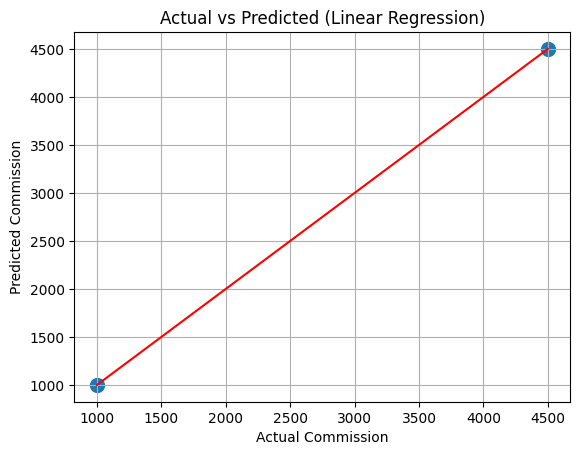

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# -----------------------
# 1. Data
# -----------------------
df = pd.DataFrame({
    "cars_sold":[1,2,3,4,5,6,7,8,9,10],
    "commission":[500,1000,1500,2000,2500,3000,3500,4000,4500,5000]
})

# -----------------------
# 2. Features & Target
# -----------------------
X = df[["cars_sold"]]
y = df["commission"]

# -----------------------
# 3. Train-Test Split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# 4. Train Model
# -----------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------
# 5. Predictions
# -----------------------
y_pred = model.predict(X_test)

# -----------------------
# 6. Evaluation
# -----------------------
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# -----------------------
# 7. Visualization (Actual vs Predicted)
# -----------------------
plt.scatter(y_test, y_pred, s=100)

plt.xlabel("Actual Commission")
plt.ylabel("Predicted Commission")
plt.title("Actual vs Predicted (Linear Regression)")
plt.grid(True)

# Perfect prediction line (reference)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

#**Cross-Validation**
Instead of a single train-test split, cross-validation divides the dataset into multiple folds for better performance estimation.

🔹 K-Fold Cross Validation:

Data is split into K equal parts (e.g., 5 or 10).

Each fold is used once as a test set, and the rest as training data.

Final performance is averaged across all folds.


**Cross-Validation (Bonus):**
While the train-test split is commonly used, for more robust evaluation, you can also use cross-validation. This involves splitting the dataset into several parts (folds), training the model on different combinations of those folds, and then averaging the performance across all splits. This approach helps to reduce variance in performance metrics.

Would you like to explore cross-validation or dive deeper into another aspect of model evaluation?

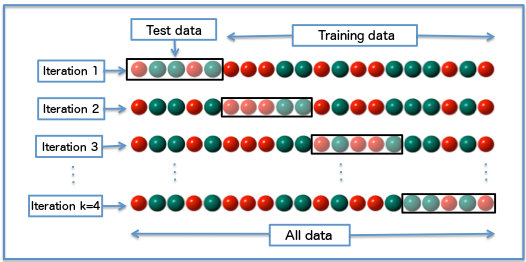

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-Validation Scores:", scores)
print("Mean Score:", scores.mean())


Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean Score: 1.0


#**Regularization (Avoiding Overfitting)**
Regularization adds a penalty to complex models to prevent overfitting.

🔹 L1 Regularization (Lasso Regression) → Shrinks some coefficients to zero (feature selection).

🔹 L2 Regularization (Ridge Regression) → Shrinks all coefficients but does not eliminate them.

🔹 Example (Using Scikit-Learn)

In [ ]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X, y)
lasso.fit(X, y)

print("Ridge Coefficients:", ridge.coef_)
print("Lasso Coefficients:", lasso.coef_)


Ridge Coefficients: [9.88023952]
Lasso Coefficients: [9.98787879]


#**Grid Search**

GridSearchCV or RandomizedSearchCV are commonly used to find the best alpha by testing multiple values.
Grid Search is a way to find the best parameters (like regularization strength) for your model by testing all possible combinations from a predefined set.

When you’re training a model, you often have hyperparameters (like alpha in Ridge or Lasso) that need to be tuned. You don’t always know what value of alpha will work best. So, Grid Search tries several values for you and picks the one that gives the best performance.

**What is alpha?**

Alpha (α) controls the strength of regularization

Small α → weak penalty → model behaves like linear regression

Large α → strong penalty → coefficients shrink more

**Why we tune alpha**

We don’t know in advance which α:

avoids overfitting

still keeps good accuracy

So we try multiple alpha values and pick the best one automatically.

Let’s say you want to find the best alpha for Ridge Regression. Here's how you can use Grid Search to find the best alpha.

1. Define the Values to Try (Grid)
We will try a few values of alpha to see which one gives the best result. For simplicity, let's try values like [0.1, 1, 10].

2. Test All Values
Grid Search will train the model with each alpha value and check which one works best.IT will do this with the help of cross validation

3. Choose the Best Alpha
Grid Search will give us the best alpha based on performance (like minimizing the error).

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Generate some simple data for regression
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a Ridge regression model
ridge = Ridge()

# Define the grid of alpha values to test
param_grid = {'alpha': [0.1, 1, 10]}  # Trying three different values for alpha

# Set up Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(ridge, param_grid, cv=5)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best alpha value found by Grid Search
best_alpha = grid_search.best_params_['alpha']
print("Best alpha from GridSearchCV:", best_alpha)

# Train the Ridge model with the best alpha
best_ridge_model = Ridge(alpha=best_alpha)
best_ridge_model.fit(X_train, y_train)

# Evaluate the model on the test set
test_score = best_ridge_model.score(X_test, y_test)
print("Test set R² score with best alpha:", test_score)


Best alpha from GridSearchCV: 0.1
Test set R² score with best alpha: 0.9373385009782622


#**Scenario: Predicting House Prices 🏠**
Let's say you're building a machine learning model to predict house prices based on features like:

Square footage

Number of bedrooms

Location

Year built

Nearby amenities

You collected a dataset of 10,000 houses and plan to train a model using train-test split.

**Steps for Model Evaluation and Visualization:**

Prepare the Data:

Split the data into training and testing sets.

Handle missing values, encode categorical features, and normalize numerical features.

**Train the Model:**

Use a regression model (e.g., linear regression, decision tree regression, or random forest regression).

**Evaluate the Model:**



The train-test split method is essential for evaluating a model, especially when you're trying to assess how well it generalizes to unseen data. Here's how it fits into the process:










**Visualizations:**

Residual Plot: To check how the residuals (errors) behave.

Actual vs Predicted Plot: To compare the true values with the predicted ones.

Feature Importance: To visualize which features contribute the most to predicting the house price.

**You decide to split the data:**

80% training (8,000 houses)

20% testing (2,000 houses)

**Problem:**
If your training set contains only luxury houses and the test set has a mix of luxury and budget houses, your model will not generalize well.

The model performs great on training data but fails on test data because it learned patterns specific to luxury houses.

This is overfitting—your model is too specialized in the training set.

🔹 Solution: Use Cross-Validation to ensure the model learns from all types of houses.

**Why Cross-Validation Helps**

Instead of just one train-test split, we use K-Fold Cross Validation (e.g., K=5).

How it works:

Step 1: Divide data into 5 equal parts (folds).

Step 2: Train the model on 4 folds, test it on the remaining 1.

Step 3: Repeat the process 5 times, each time changing the test fold.

Step 4: Average the results to get a better estimate of model performance.

🔹 Benefit: The model sees different types of houses in different folds, preventing it from being biased towards any single group.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Dummy dataset (house size vs price)
X = np.array([[1000], [1500], [1800], [2200], [2500], [3000], [3500], [4000], [5000], [6000]])
y = np.array([200, 250, 270, 310, 350, 400, 460, 500, 600, 700])  # Prices in $1000s

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross-Validation Scores:", scores)
print("Mean Score:", scores.mean())


Cross-Validation Scores: [0.94426455 0.69048712 0.99530236 0.8171636  0.98036376]
Mean Score: 0.8855162768525349


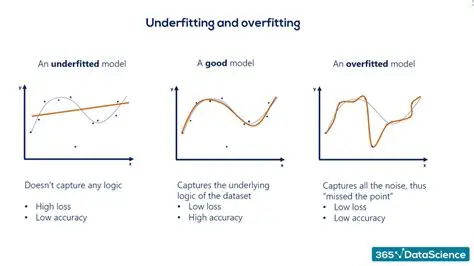

**Why Regularization is Needed (Prevent Overfitting)**

Now, suppose your model includes too many features:

Number of windows

Type of flooring

Color of walls

Number of trees in the backyard

Some of these might not affect house prices, but your model memorizes the training data instead of learning general patterns. This is overfitting again.

Solution: Apply Regularization

L1 Regularization (Lasso Regression): Eliminates useless features.

L2 Regularization (Ridge Regression): Prevents overly large coefficients.

In [ ]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)  # L2 regularization
lasso = Lasso(alpha=0.1)  # L1 regularization

ridge.fit(X, y)
lasso.fit(X, y)

print("Ridge Coefficients:", ridge.coef_)
print("Lasso Coefficients:", lasso.coef_)


Ridge Coefficients: [9.88023952]
Lasso Coefficients: [9.98787879]


Ridge Regression Cross-Validation (Average MSE): 0.5192628644116297
Lasso Regression Cross-Validation (Average MSE): 0.6034418884128859

Ridge Regression (Test Set):
Mean Absolute Error: 0.5332039182571153
Mean Squared Error: 0.5558034669932211
Root Mean Squared Error: 0.7455222779992702
R² Score: 0.5758549611440126

Lasso Regression (Test Set):
Mean Absolute Error: 0.5816074623949868
Mean Squared Error: 0.6135115198058131
Root Mean Squared Error: 0.7832697618354822
R² Score: 0.5318167610318159


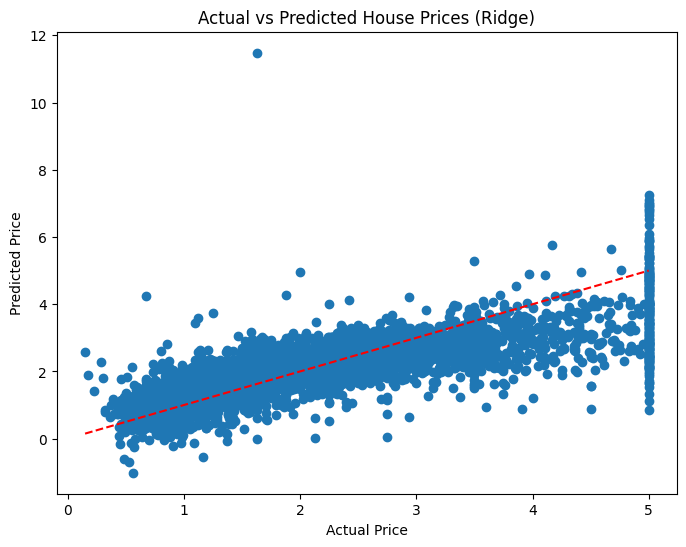

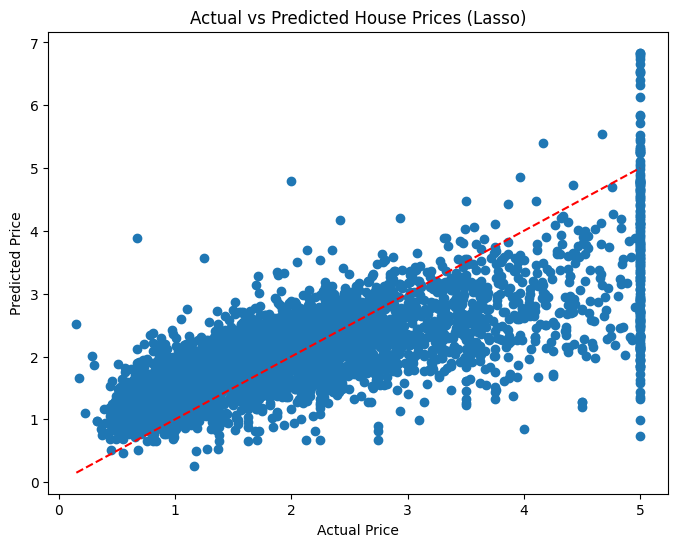

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load California Housing dataset (real data)
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target)

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cross-validation with Ridge and Lasso
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)

# Cross-validation for Ridge (5 folds)
ridge_cv_scores = cross_val_score(ridge_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
# Cross-validation for Lasso (5 folds)
lasso_cv_scores = cross_val_score(lasso_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Convert cross-validation results to positive MSE
ridge_cv_scores = -ridge_cv_scores
lasso_cv_scores = -lasso_cv_scores

# Print average cross-validation scores for both models
print("Ridge Regression Cross-Validation (Average MSE):", np.mean(ridge_cv_scores))
print("Lasso Regression Cross-Validation (Average MSE):", np.mean(lasso_cv_scores))

# Train Ridge and Lasso on the full training set
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Predictions on the test set
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

# Model evaluation for Ridge
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

# Model evaluation for Lasso
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# Print evaluation metrics
print("\nRidge Regression (Test Set):")
print(f"Mean Absolute Error: {ridge_mae}")
print(f"Mean Squared Error: {ridge_mse}")
print(f"Root Mean Squared Error: {ridge_rmse}")
print(f"R² Score: {ridge_r2}")

print("\nLasso Regression (Test Set):")
print(f"Mean Absolute Error: {lasso_mae}")
print(f"Mean Squared Error: {lasso_mse}")
print(f"Root Mean Squared Error: {lasso_rmse}")
print(f"R² Score: {lasso_r2}")

# Visualization 1: Actual vs Predicted (Ridge)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, ridge_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Actual vs Predicted House Prices (Ridge)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

# Visualization 2: Actual vs Predicted (Lasso)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lasso_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Actual vs Predicted House Prices (Lasso)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()


MAE: What it means

On average, the model’s predictions are off by about 0.58 units


MSE: What it means : Measures average squared prediction error , Larger mistakes are penalized more

RMSE > MAE → indicates some larger errors exist

R2-0.53 = moderate model performance

(Lower is better)

Ridge CV MSE = 0.52

Lasso CV MSE = 0.60

Meaning:

Across multiple folds of unseen data, Ridge consistently makes smaller errors than Lasso.

This already suggests Ridge generalizes better for this dataset.

| Metric | What it tells us        |
| ------ | ----------------------- |
| MAE    | Average error size      |
| MSE    | Penalizes large errors  |
| RMSE   | Typical error magnitude |
| R²     | Variance explained      |


#One-line teaching takeaway

R² tells us how much we explain; MAE and RMSE tell us how wrong we are.

#This pattern usually means:

Features are correlated

Most features contain useful information

Lasso may be removing some important features by forcing coefficients to zero

--Ridge keeps all features but shrinks them, leading to better predictive accuracy.

| Situation                | Use   |
| ------------------------ | ----- |
| All features matter      | Ridge |
| Many irrelevant features | Lasso |
| Correlated features      | Ridge |
| Need feature selection   | Lasso |
| Best prediction accuracy | Ridge |
| Want a simpler model     | Lasso |


#Complete Pipeline

Data
 ↓
Train–Test Split
 ↓
Baseline Linear Regression
 ↓
Cross-Validation
 ↓
Ridge / Lasso
 ↓
GridSearch (alpha)
 ↓
Final Test Evaluation


1️⃣ Underfitting
What it means

👉 The model is too simple to learn the pattern in the data.

Doesn’t learn well from training data

Performs poorly on both training and test data

Example

Trying to fit a straight line to data that clearly curves.

Symptoms

Low R² on training data

Low R² on test data

📌 Cause: Model is too simple

2️⃣ Overfitting
What it means

👉 The model is too complex and memorizes the training data.

Performs very well on training data

Performs poorly on unseen (test) data

Example

Using a very high-degree polynomial that passes through every point.

Symptoms

Very high R² on training data

Low R² on test data

📌 Cause: Model is too complex

3️⃣ Bias
What it means

👉 Error due to wrong assumptions in the model.

High bias = model is too simple

Misses important patterns

Example

Predicting exam score using only hours studied, ignoring sleep and stress.

📌 Bias leads to underfitting

4️⃣ Variance
What it means

👉 Error due to too much sensitivity to training data.

Model changes a lot with small data changes

Learns noise instead of pattern

Example

A model that gives very different results if one data point changes.

📌 Variance leads to overfitting



| Situation    | Bias     | Variance | Result              |
| ------------ | -------- | -------- | ------------------- |
| Underfitting | High     | Low      | Poor model          |
| Overfitting  | Low      | High     | Poor generalization |
| Good fit     | Balanced | Balanced | Best model          |


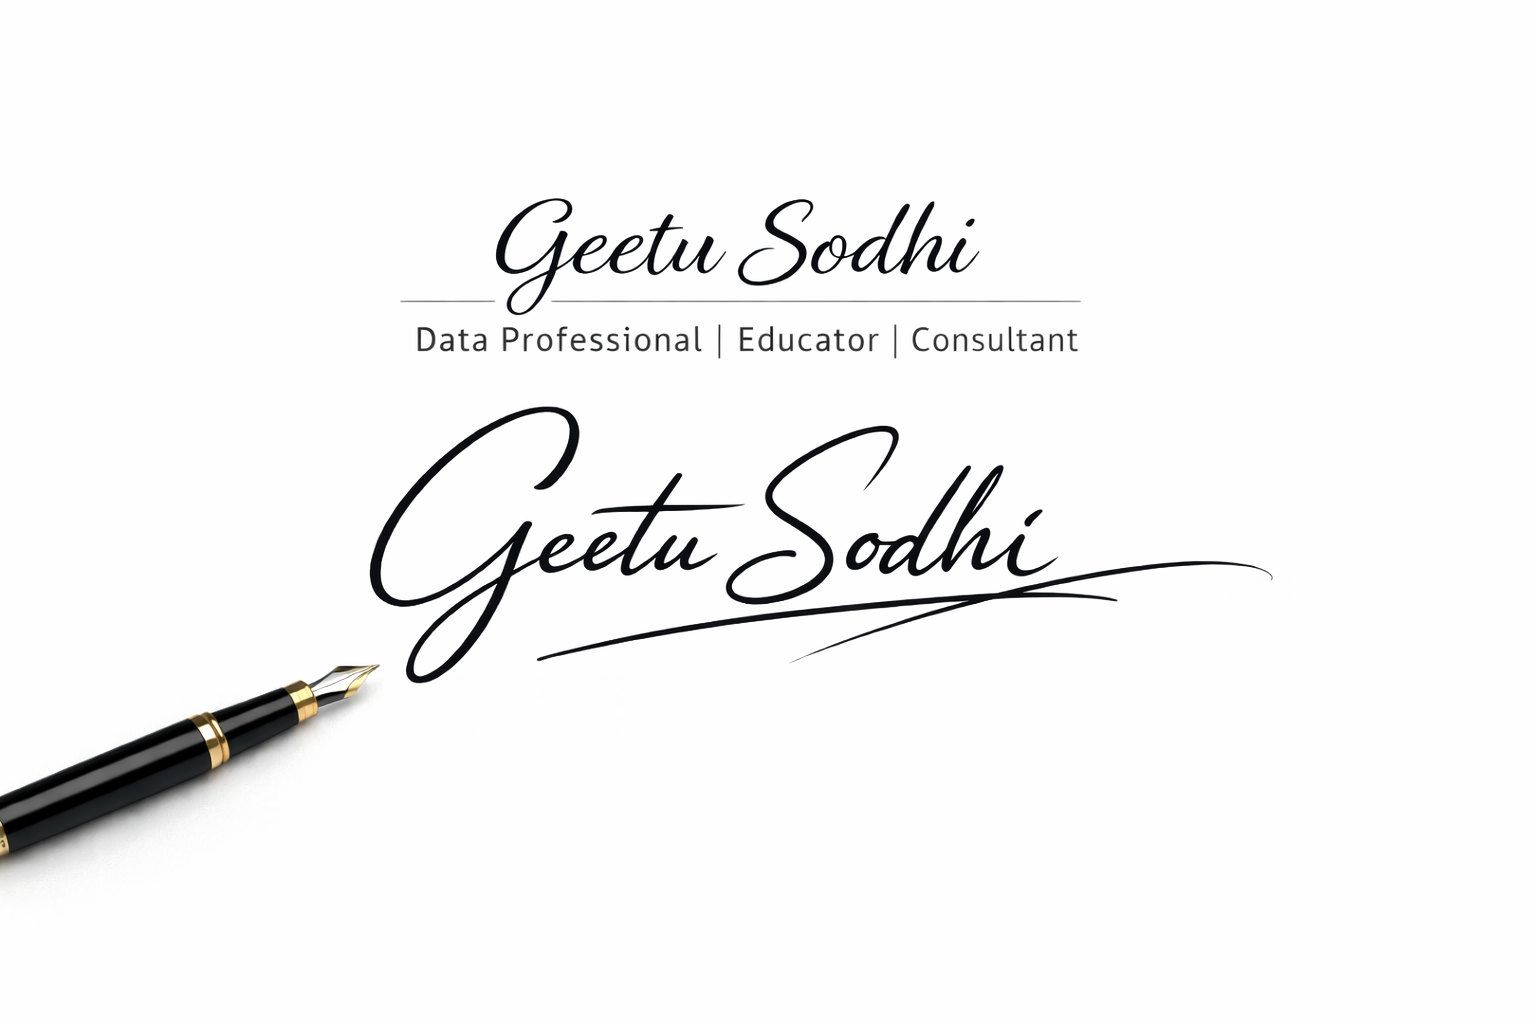